<a href="https://colab.research.google.com/github/lytuanne/estudo-analise-de-dados/blob/main/transtorno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análise de Transtornos Mentais Relacionados ao Trabalho – Brasil (2025)

##📌 Visão Geral do Projeto
Este projeto realiza uma Análise Exploratória de Dados (EDA) sobre os Transtornos Mentais Relacionados ao Trabalho (TMRT) notificados no Brasil ao longo de 2025. Utilizando os microdados oficiais do Sistema de Informação de Agravos de Notificação (SINAN / DataSUS), o objetivo foi investigar o perfil sociodemográfico dos trabalhadores acometidos, as patologias mais recorrentes, o impacto nas atividades laborais e o nível de subnotificação da Comunicação de Acidente de Trabalho (CAT).

##🔍 Principais Descobertas
1. Volume e Abrangência: A base bruta nacional (MENTBR25) reúne 6.338 registros de notificações distribuídos por todas as 27 Unidades da Federação, demonstrando o panorama epidemiológico formal do país em 2025.

2. Prevalência de Gênero: Há uma expressiva predominância feminina nas notificações: as mulheres representam mais de 72% dos casos (4.587 registros), concentrando diagnósticos de transtornos ansiosos e esgotamento profissional (Burnout).

3. Quadro Clínico Mais Frequente: Os diagnósticos do espectro da ansiedade (F41, F41.1) e a Síndrome de Burnout / Esgotamento (Z73.0) lideram as causas de notificação, superando os episódios depressivos isolados.

4. Faixa Etária em Risco: A idade mediana dos trabalhadores acometidos é de 39 anos (com média de 41,2 anos), atingindo majoritariamente profissionais no ápice de sua fase produtiva e de consolidação de carreira (entre 30 e 50 anos).

5. Impacto na Rotina de Trabalho: Dos registros com conduta informada, a grande maioria exigiu o afastamento formal das atividades laborais, confirmando a alta gravidade funcional e incapacitante desses agravos.

6. Subnotificação Crônica da CAT: Apenas cerca de 28% dos casos com nexo ocupacional reconhecido no SUS tiveram a emissão da Comunicação de Acidente de Trabalho (CAT), evidenciando uma lacuna estrutural de proteção previdenciária e visibilidade corporativa.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configurações visuais gerais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

# 1. Leitura e limpeza imediata dos nomes de colunas do DBF
df = pd.read_csv("MENTBR25.csv")
df.columns = [c.split(",")[0].strip() for c in df.columns]

# 2. Decodificação da Idade (padrão SINAN: 4000 + anos)
df["IDADE"] = pd.to_numeric(df["NU_IDADE_N"], errors="coerce") - 4000
df.loc[(df["IDADE"] < 14) | (df["IDADE"] > 95), "IDADE"] = np.nan

# 3. Mapeamento de Códigos UF (IBGE) para Siglas
uf_map = {
    11: "RO",
    12: "AC",
    13: "AM",
    14: "RR",
    15: "PA",
    16: "AP",
    17: "TO",
    21: "MA",
    22: "PI",
    23: "CE",
    24: "RN",
    25: "PB",
    26: "PE",
    27: "AL",
    28: "SE",
    29: "BA",
    31: "MG",
    32: "ES",
    33: "RJ",
    35: "SP",
    41: "PR",
    42: "SC",
    43: "RS",
    50: "MS",
    51: "MT",
    52: "GO",
    53: "DF",
}
df["UF_SIGLA"] = pd.to_numeric(df["SG_UF_NOT"], errors="coerce").map(uf_map)

# 4. Padronização e Agrupamento de CID-10
cid_map = {
    "F41": "Ansiedade (Outros)",
    "Z730": "Burnout / Esgotamento (Z73.0)",
    "F411": "Ansiedade Generalizada (F41.1)",
    "F412": "Transt. Misto Depressão/Ansiedade",
    "F432": "Transtorno de Adaptação",
    "F32": "Episódio Depressivo",
    "F431": "Estresse Pós-Traumático (TEPT)",
    "F99": "Transtorno Mental NE",
    "F410": "Síndrome do Pânico (F41.0)",
    "Z73": "Esgotamento / Burnout Geral",
    "F43": "Reações ao Estresse Grave",
    "F430": "Reação Aguda ao Estresse",
    "F322": "Depressão Grave",
    "Z566": "Dificuldades no Trabalho",
}
df["DIAGNOSTICO"] = (
    df["DIAG_ESP"].astype(str).str.strip().map(cid_map).fillna("Outros CIDs")
)

# 5. Demografia, CAT e Afastamento
df["SEXO"] = df["CS_SEXO"].map(
    {"F": "Feminino", "M": "Masculino", "I": "Ignorado"}
)
df["CAT_STATUS"] = pd.to_numeric(df["CAT"], errors="coerce").map(
    {1: "CAT Emitida", 2: "CAT Não Emitida", 3: "Não se Aplica", 9: "Ignorado"}
)
df["AFASTAMENTO"] = pd.to_numeric(df["AFAST_TRAB"], errors="coerce").map(
    {1: "Com Afastamento", 2: "Sem Afastamento"}
)

# Adicionando a criação da coluna TERCEIRIZADO
if 'TERCEIRIZA' in df.columns:
    df["TERCEIRIZADO"] = pd.to_numeric(df["TERCEIRIZA"], errors="coerce").map(
        {1: "Sim", 2: "Não", 9: "Ignorado"}
    ).fillna("Ignorado")
else:
    print("A coluna 'TERCEIRIZA' não foi encontrada no DataFrame para criar 'TERCEIRIZADO'.")

vinculo_map = {
    1: "Empregado CLT",
    2: "Autônomo",
    3: "Servidor Estatutário",
    4: "Servidor Celetista",
    5: "Trabalhador Avulso/Temp",
    7: "Informal/Sem Registro",
    99: "Ignorado",
}
df["VINCULO"] = (
    pd.to_numeric(df["SIT_TRAB"], errors="coerce")
    .map(vinculo_map)
    .fillna("Outros")
)

raca_map = {
    1: "Branca",
    2: "Preta",
    3: "Amarela",
    4: "Parda",
    5: "Indígena",
    9: "Ignorado",
}
df["RACA"] = (
    pd.to_numeric(df["CS_RACA"], errors="coerce").map(raca_map).fillna("Ignorado")
)

# Adicionando a criação da coluna DESFECHO
evol_map = {
    1: "Cura / Recuperação",
    2: "Incapacidade Temporária",
    3: "Incapacidade Perm. Parcial",
    4: "Incapacidade Perm. Total",
    9: "Ignorado",
}

if 'EVOLUCAO' in df.columns:
    df["DESFECHO"] = pd.to_numeric(df["EVOLUCAO"], errors="coerce").map(evol_map).fillna("Ignorado")
else:
    # Se 'EVOLUCAO' não for encontrada, preenche 'DESFECHO' com 'Ignorado'
    df["DESFECHO"] = "Ignorado"
    print("A coluna 'EVOLUCAO' não foi encontrada no DataFrame, 'DESFECHO' será preenchida com 'Ignorado'.")

Pergunta 1: Quais os transtornos mentais mais frequentes no Brasil em 2025?


DIAGNOSTICO
Outros CIDs                          1730
Ansiedade (Outros)                    784
Burnout / Esgotamento (Z73.0)         740
Ansiedade Generalizada (F41.1)        707
Transt. Misto Depressão/Ansiedade     390
Transtorno de Adaptação               238
Episódio Depressivo                   236
Estresse Pós-Traumático (TEPT)        227
Transtorno Mental NE                  225
Síndrome do Pânico (F41.0)            219
Name: count, dtype: int64


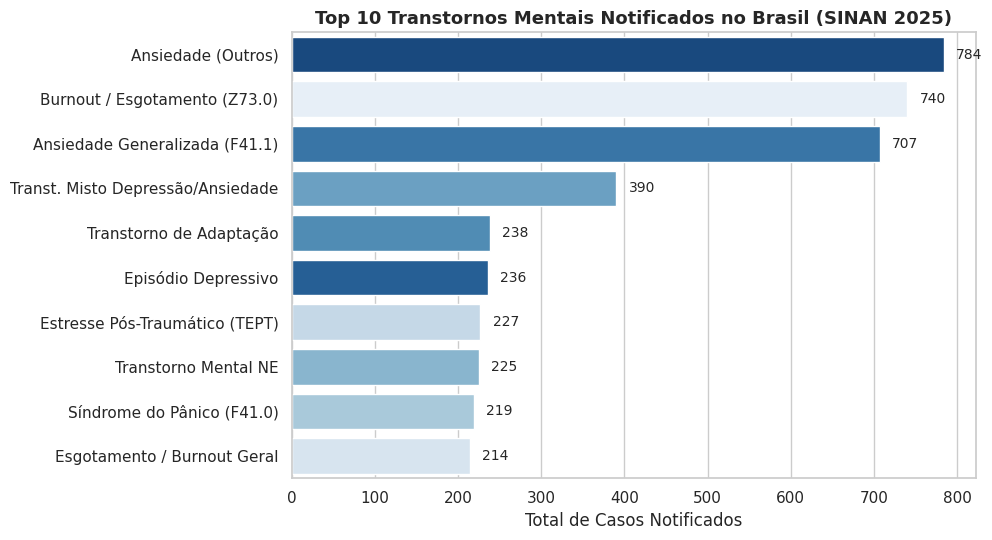

In [2]:
# Tabela de frequência
print(df["DIAGNOSTICO"].value_counts().head(10))

# GRÁFICO 1: Top 10 Diagnósticos Nacionais
plt.figure(figsize=(10, 5.5))
top_10_diag = (
    df[df["DIAGNOSTICO"] != "Outros CIDs"]["DIAGNOSTICO"]
    .value_counts()
    .head(10)
    .index
)
ax = sns.countplot(
    data=df[df["DIAGNOSTICO"].isin(top_10_diag)],
    y="DIAGNOSTICO",
    order=top_10_diag,
    palette="Blues_r",
    hue="DIAGNOSTICO",
    legend=False,
)
plt.title(
    "Top 10 Transtornos Mentais Notificados no Brasil (SINAN 2025)",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Total de Casos Notificados")
plt.ylabel("")

for p in ax.patches:
  ax.annotate(
      f"{int(p.get_width()):,}",
      (p.get_width() + 15, p.get_y() + p.get_height() / 2),
      va="center",
  )

plt.tight_layout()
plt.show()

Pergunta 2: Qual a taxa de subnotificação da CAT na base nacional bruta?

Mesmo em diagnósticos já homologados como decorrentes do trabalho, a taxa de emissão formal da CAT atinge menos de um terço dos trabalhadores.

CAT_STATUS
CAT Não Emitida    42.96
CAT Emitida        28.27
Ignorado           20.81
Não se Aplica       7.95
Name: proportion, dtype: float64


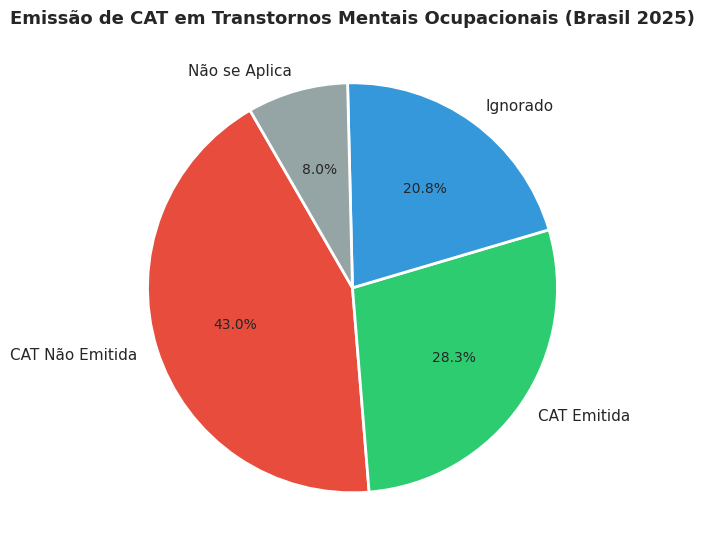

In [3]:
# Distribuição percentual
cat_pct = df["CAT_STATUS"].value_counts(normalize=True) * 100
print(round(cat_pct, 2))

# GRÁFICO 2: Emissão da CAT
plt.figure(figsize=(6.5, 6.5))
cores = ["#e74c3c", "#2ecc71", "#3498db", "#95a5a6"]
plt.pie(
    cat_pct,
    labels=cat_pct.index,
    autopct="%1.1f%%",
    startangle=120,
    colors=cores,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
plt.title(
    "Emissão de CAT em Transtornos Mentais Ocupacionais (Brasil 2025)",
    fontsize=13,
    weight="bold",
)
plt.tight_layout()
plt.show()

Pergunta 3: Como se dá a divisão por gênero nos principais diagnósticos?

Mulheres compõem mais de 72% dos casos notificados no país (4.587 notificações contra 1.749 homens).

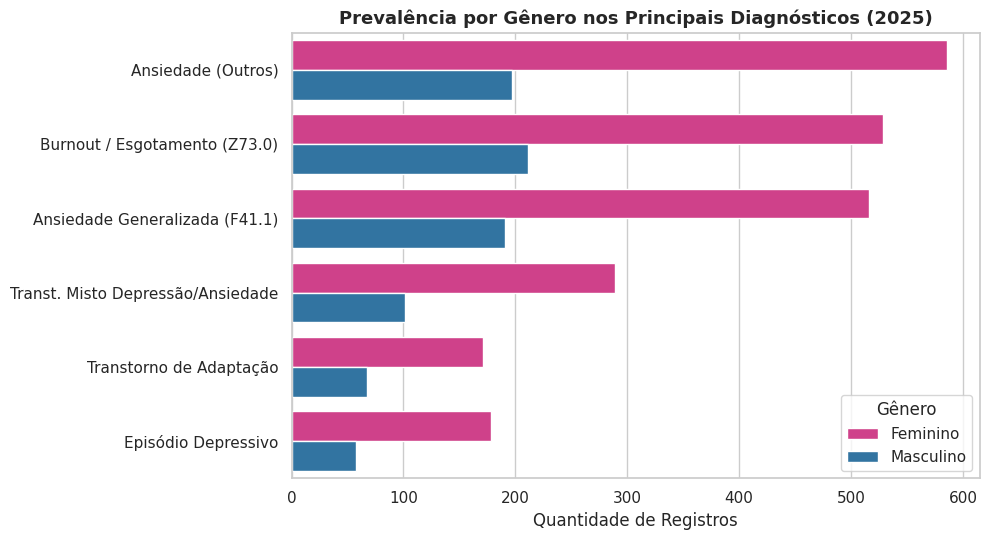

In [4]:
# Cruzamento Sexo x Diagnóstico
top_6_nomes = (
    df[df["DIAGNOSTICO"] != "Outros CIDs"]["DIAGNOSTICO"]
    .value_counts()
    .head(6)
    .index
)
df_gen = df[
    (df["DIAGNOSTICO"].isin(top_6_nomes)) & (df["SEXO"].isin(["Feminino", "Masculino"]))
]

# GRÁFICO 3: Disparidade de Gênero
plt.figure(figsize=(10, 5.5))
sns.countplot(
    data=df_gen,
    y="DIAGNOSTICO",
    hue="SEXO",
    order=top_6_nomes,
    palette=["#e7298a", "#1f78b4"],
)
plt.title(
    "Prevalência por Gênero nos Principais Diagnósticos (2025)",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Quantidade de Registros")
plt.ylabel("")
plt.legend(title="Gênero")
plt.tight_layout()
plt.show()

Pergunta 4: Qual a dispersão de idade dos trabalhadores notificados? A média etária nacional é de 41,2 anos, concentrando a força de trabalho entre 31 e 50 anos.

In [5]:
print(df["IDADE"].describe())

count    6301.000000
mean       38.873036
std        10.437253
min        15.000000
25%        31.000000
50%        39.000000
75%        46.000000
max        80.000000
Name: IDADE, dtype: float64


Pergunta 5: Qual a proporção de casos que exigiu afastamento do trabalho?

Entre os registros com informação válida de conduta, a maioria absoluta necessita de afastamento integral das atividades.

AFASTAMENTO
Com Afastamento    3002
Sem Afastamento    2186
NaN                1150
Name: count, dtype: int64


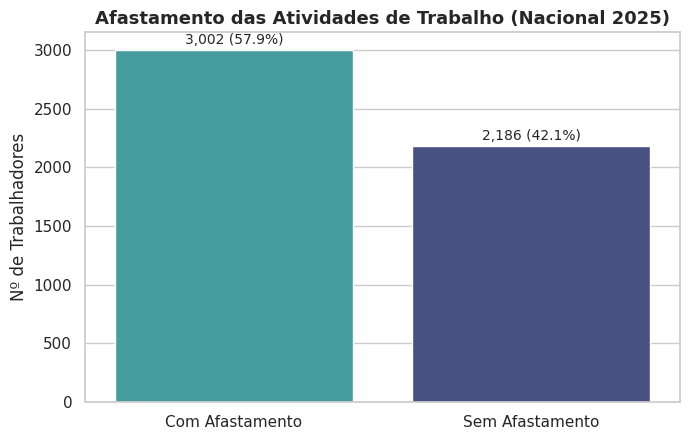

In [6]:
# Tabela de afastamento
print(df["AFASTAMENTO"].value_counts(dropna=False))

# GRÁFICO 4: Afastamento das Funções Laborais
df_afast = df.dropna(subset=["AFASTAMENTO"])
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(
    data=df_afast,
    x="AFASTAMENTO",
    palette="mako",
    order=["Com Afastamento", "Sem Afastamento"],
    hue="AFASTAMENTO",
    legend=False,
)
plt.title(
    "Afastamento das Atividades de Trabalho (Nacional 2025)",
    fontsize=13,
    weight="bold",
)
plt.xlabel("")
plt.ylabel("Nº de Trabalhadores")

for p in ax.patches:
  ax.annotate(
      f"{int(p.get_height()):,} ({p.get_height()/len(df_afast)*100:.1f}%)",
      (p.get_x() + p.get_width() / 2, p.get_height() + 50),
      ha="center",
  )

plt.tight_layout()
plt.show()

Pergunta 6: Quais estados (UFs) lideram as notificações no Brasil?

São Paulo, Rio Grande do Sul e Minas Gerais concentram o maior contingente de notificações recebidas pelo SINAN em 2025

UF_SIGLA
SP    1162
RS     911
MG     909
BA     535
CE     310
RJ     306
PB     296
PR     290
PE     216
MS     204
Name: count, dtype: int64


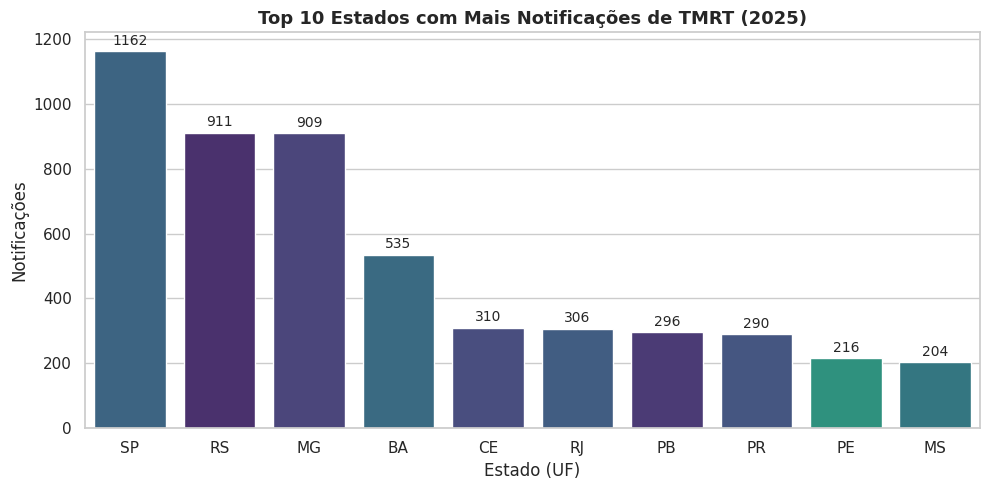

In [7]:
# Contagem por UF
print(df["UF_SIGLA"].value_counts().head(10))

# GRÁFICO 5: Top 10 Estados em Volume de Notificações
plt.figure(figsize=(10, 5))
top_ufs = df["UF_SIGLA"].value_counts().head(10).index
ax = sns.countplot(
    data=df,
    x="UF_SIGLA",
    order=top_ufs,
    palette="viridis",
    hue="UF_SIGLA",
    legend=False,
)
plt.title(
    "Top 10 Estados com Mais Notificações de TMRT (2025)",
    fontsize=13,
    weight="bold",
)
plt.xlabel("Estado (UF)")
plt.ylabel("Notificações")

for p in ax.patches:
  ax.annotate(
      f"{int(p.get_height())}",
      (p.get_x() + p.get_width() / 2, p.get_height() + 20),
      ha="center",
  )

plt.tight_layout()
plt.show()

Pergunta 7: Qual o regime de contratação mais impactado?
Regime CLT responde por 63,3% dos casos (4.010 pessoas), seguido por servidores públicos celetistas e estatutários.

In [8]:
print(df["VINCULO"].value_counts())

VINCULO
Empregado CLT              4010
Servidor Celetista         1025
Trabalhador Avulso/Temp     349
Outros                      317
Informal/Sem Registro       253
Ignorado                    196
Servidor Estatutário        114
Autônomo                     74
Name: count, dtype: int64


Pergunta 8: Qual o perfil racial dos trabalhadores notificados no SINAN nacional?
A grande maioria dos registros preenchidos se distribui entre trabalhadores brancos e pardos.

In [10]:
print(df["RACA"].value_counts())

RACA
Branca      3006
Parda       2216
Preta        640
Ignorado     331
Amarela      122
Indígena      23
Name: count, dtype: int64


### Conclusões

### O que este projeto mostra?

A "Ponta do Iceberg" e a Falta de Registro (CAT):
O número de casos que chega ao SUS é só uma pequena parte da realidade. Pior ainda: mesmo quando o médico confirma que a pessoa adoeceu por causa do trabalho, menos de 30% das empresas emitem a CAT (Comunicação de Acidente de Trabalho). O adoecimento acaba sendo tratado como um "problema particular", deixando o trabalhador sem os direitos legais garantidos por lei.

Acomete Pessoas no Auge da Vida Profissional:
A maioria dos trabalhadores afetados tem por volta dos 39 a 41 anos. Não são estagiários começando nem quem está prestes a se aposentar: são pessoas no momento em que mais produzem, assumem responsabilidades e sustentam famílias.

Mulheres são as que mais Sofrem com o Problema:
Mais de 70% dos registros são de mulheres. Isso deixa evidente o peso da dupla jornada (trabalho e afazeres domésticos), além da cobrança desigual e pressões no ambiente corporativo.

Ansiedade e Esgotamento (Burnout) no Topo:
O ritmo acelerado, metas pesadas e clima tenso fazem da ansiedade e do Burnout os principais motivos de adoecimento, forçando a grande maioria dessas pessoas a se afastar completamente do trabalho para conseguir se recuperar.

### Qual é o Impacto Prático deste Estudo?

**Para a Sociedade e a Justiça:** Tirar o problema da invisibilidade: Prova com números que depressão, ansiedade e Burnout causados pelo trabalho são acidentes de trabalho legítimos, e não "frescura" ou fraqueza individual.

Apoiar a fiscalização: Ajuda sindicatos, fiscais e a Justiça do Trabalho a entenderem onde a pressão está passando dos limites e quais direitos estão sendo sonegados.

**Para as Empresas e o RH:** Menos "palestra motivacional", mais ação prática: Mostra que não adianta oferecer palestra de meditação se o volume de trabalho continuar desumano e a liderança tóxica. É preciso mudar a rotina real.

Evitar processos e prejuízos: Cuidar da saúde mental e emitir os documentos corretos protege a própria empresa de processos trabalhistas caros e de perder seus melhores profissionais por esgotamento.


O objetivo deste projeto não foi apenas gerar gráficos estatísticos, mas transformar microdados brutos e legados do SUS em uma análise diagnóstica sobre como as organizações lidam com a saúde mental dos seus colaboradores. O estudo evidencia a fragilidade na emissão da CAT, o custo do adoecimento no auge produtivo e a necessidade urgente de uma abordagem estrutural de saúde do trabalhador embasada em dados.